In [1]:
%%bash
jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Solution", "Main"]' \
  --output ../exercises/01_data-preprocessing.ipynb 01_data-preprocessing.ipynb

jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Student", "Main"]' \
  --output ../solutions/01_data-preprocessing.ipynb 01_data-preprocessing.ipynb


[NbConvertApp] Converting notebook 01_data-preprocessing.ipynb to notebook
[NbConvertApp] Writing 298147 bytes to ../exercises/01_data-preprocessing.ipynb
[NbConvertApp] Converting notebook 01_data-preprocessing.ipynb to notebook
[NbConvertApp] Writing 299279 bytes to ../solutions/01_data-preprocessing.ipynb


# Preprocessing data
In this notebook, we will prepare data from a file called `florida_weather_data_preprocess.csv`

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1: load data using the pandas library

In [25]:
file_path = '../../projects/EnergyPrediction/data/florida_weather_data_preprocess.csv'
df_weather = ...

In [26]:
file_path = '../../projects/EnergyPrediction/data/florida_weather_data_preprocess.csv'
df_weather = pd.read_csv(file_path, index_col=0)

In [27]:
df_weather

,Navn,Stasjon,Tid(norsk normaltid),Nedbør (1 t),Maksimumstemperatur (1 t),Minimumstemperatur (1 t),Middelvind,Høyeste middelvind (1 t)
35000,Bergen - Florida,SN50540,28.12.2024 09:00,1.9,7.9,7.7,4.6,5.5
35001,Bergen - Florida,SN50540,28.12.2024 10:00,2.9,8.4,7.9,4.1,5.1
35002,Bergen - Florida,SN50540,28.12.2024 11:00,3.2,8.5,8.4,3.7,4.2
35003,Bergen - Florida,SN50540,28.12.2024 12:00,2.1,8.4,8.4,4.4,4.4
35004,Bergen - Florida,SN50540,28.12.2024 13:00,-1.5,8.5,8.4,4.3,4.6
...,...,...,...,...,...,...,...,...
41331,Bergen - Florida,SN50540,18.09.2025 04:00,0.0,13.2,12.8,5.5,5.5
41332,Bergen - Florida,SN50540,18.09.2025 05:00,0.0,13.4,12.9,4.7,6.6
41333,Bergen - Florida,SN50540,18.09.2025 06:00,1.3,12.8,11.9,6.7,7.1
41334,Bergen - Florida,SN50540,18.09.2025 07:00,1.3,13.1,12.2,6.1,8.9


## Step 2: quality control
For quality control, we must look at the data. We can plot them to do so.
We first extract the data we need

In [28]:
df_weather_extract = df_weather.iloc[:,3:].sort_index().astype(float)
df_weather_extract.columns = ['Pr','Tmax','Tmin','w_mean','w_max']

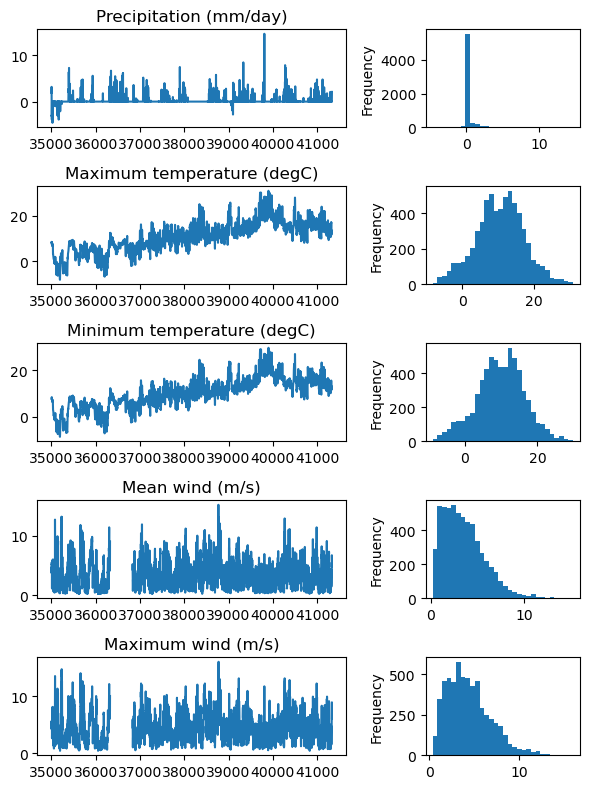

In [29]:
fig, axs = plt.subplots(5,2,figsize=(6,8), width_ratios=[2,1])

df_weather_extract.Pr.plot(ax=axs[0,0])
df_weather_extract.Tmax.plot(ax=axs[1,0])
df_weather_extract.Tmin.plot(ax=axs[2,0])
df_weather_extract.w_mean.plot(ax=axs[3,0])
df_weather_extract.w_max.plot(ax=axs[4,0])

df_weather_extract.Pr.plot.hist(ax=axs[0,1], bins=30)
df_weather_extract.Tmax.plot.hist(ax=axs[1,1], bins=30)
df_weather_extract.Tmin.plot.hist(ax=axs[2,1], bins=30)
df_weather_extract.w_mean.plot.hist(ax=axs[3,1], bins=30)
df_weather_extract.w_max.plot.hist(ax=axs[4,1], bins=30)

axs[0,0].set_title('Precipitation (mm/day)')
axs[1,0].set_title('Maximum temperature (degC)')
axs[2,0].set_title('Minimum temperature (degC)')
axs[3,0].set_title('Mean wind (m/s)')
axs[4,0].set_title('Maximum wind (m/s)')

plt.tight_layout()

### Issues?

1. Some precipitation data are negative
2. Wind data is missing for a good part of the samples

### Only select data with good quality

In [30]:
qc_data_index = (df_weather_extract.w_max.notnull() &
                 df_weather_extract.w_mean.notnull()&
                 (df_weather_extract.Pr >= 0 ) )
df_weather_extract_qc = df_weather_extract.loc[qc_data_index]

print(df_weather_extract.shape)
print(df_weather_extract_qc.shape)

(6336, 5)
(5682, 5)


## Step 3: reshape data
We need to define which one is an input which one is an output. 
We choose precipitation as output

In [31]:
X = df_weather_extract_qc[['Tmax','Tmin','w_mean','w_max']].values
y = df_weather_extract_qc['Pr'].values
print(X.shape, y.shape)
y = y.reshape(-1,1)
print(X.shape, y.shape)

(5682, 4) (5682,)
(5682, 4) (5682, 1)


In [32]:
X

array([[ 7.9,  7.7,  4.6,  5.5],
       [ 8.4,  7.9,  4.1,  5.1],
       [ 8.5,  8.4,  3.7,  4.2],
       ...,
       [12.8, 11.9,  6.7,  7.1],
       [13.1, 12.2,  6.1,  8.9],
       [13.4, 12.9,  6. ,  6.1]], shape=(5682, 4))

## Step 4: tranform the data


In [49]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, Binarizer
from sklearn.compose import ColumnTransformer # apply different transformation to each column

In [50]:
X

array([[ 7.9,  7.7,  4.6,  5.5],
       [ 8.4,  7.9,  4.1,  5.1],
       [ 8.5,  8.4,  3.7,  4.2],
       ...,
       [12.8, 11.9,  6.7,  7.1],
       [13.1, 12.2,  6.1,  8.9],
       [13.4, 12.9,  6. ,  6.1]], shape=(5682, 4))

In [51]:
preprocessor_X = ColumnTransformer(
    transformers=[('Standardize', StandardScaler(), [0,1]),
                  ('Power transform', PowerTransformer(standardize=True), [2,3]),
                  ])
preprocessor_X.fit(X)

X_transform = preprocessor_X.transform(X)


# Transform rainfall into categories: binarize
preprocessor_y = Binarizer(threshold=.1)
preprocessor_y.fit(y)
y_transform = preprocessor_y.transform(y)

preprocessor_X

,transformers,"[('Standardize', ...), ('Power transform', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


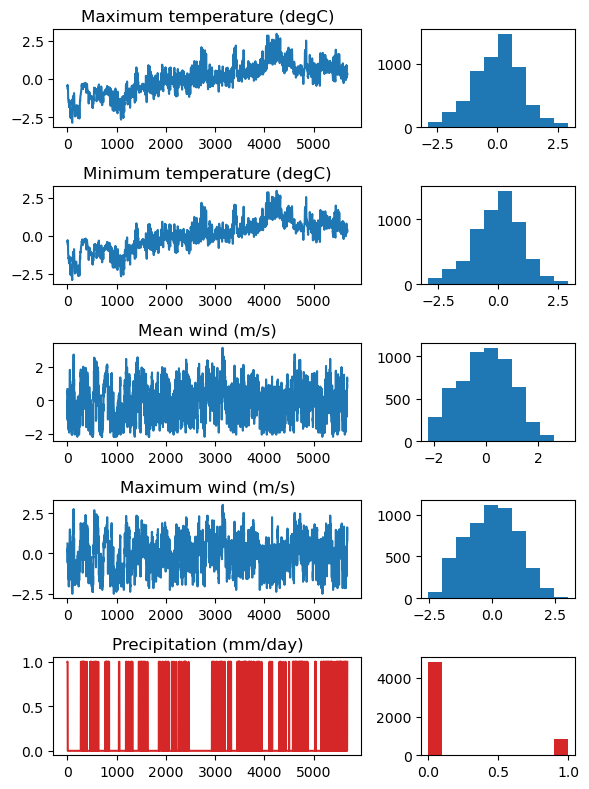

In [52]:
fig, axs = plt.subplots(5,2,figsize=(6,8), width_ratios=[2,1])

axs[0,0].plot(X_transform[:,0])
axs[1,0].plot(X_transform[:,1])
axs[2,0].plot(X_transform[:,2])
axs[3,0].plot(X_transform[:,3])
axs[4,0].plot(y_transform[:,0], color='C3')

axs[0,1].hist(X_transform[:,0])
axs[1,1].hist(X_transform[:,1])
axs[2,1].hist(X_transform[:,2])
axs[3,1].hist(X_transform[:,3])
axs[4,1].hist(y_transform[:,0], color='C3')


axs[4,0].set_title('Precipitation (mm/day)')
axs[0,0].set_title('Maximum temperature (degC)')
axs[1,0].set_title('Minimum temperature (degC)')
axs[2,0].set_title('Mean wind (m/s)')
axs[3,0].set_title('Maximum wind (m/s)')

plt.tight_layout()

In [53]:
X_trainval, X_test, y_trainval, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.33)
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X_trainval, y_trainval, test_size=0.33)


NameError: name 'sklearn' is not defined